# Quan hệ giữa sales và inventory

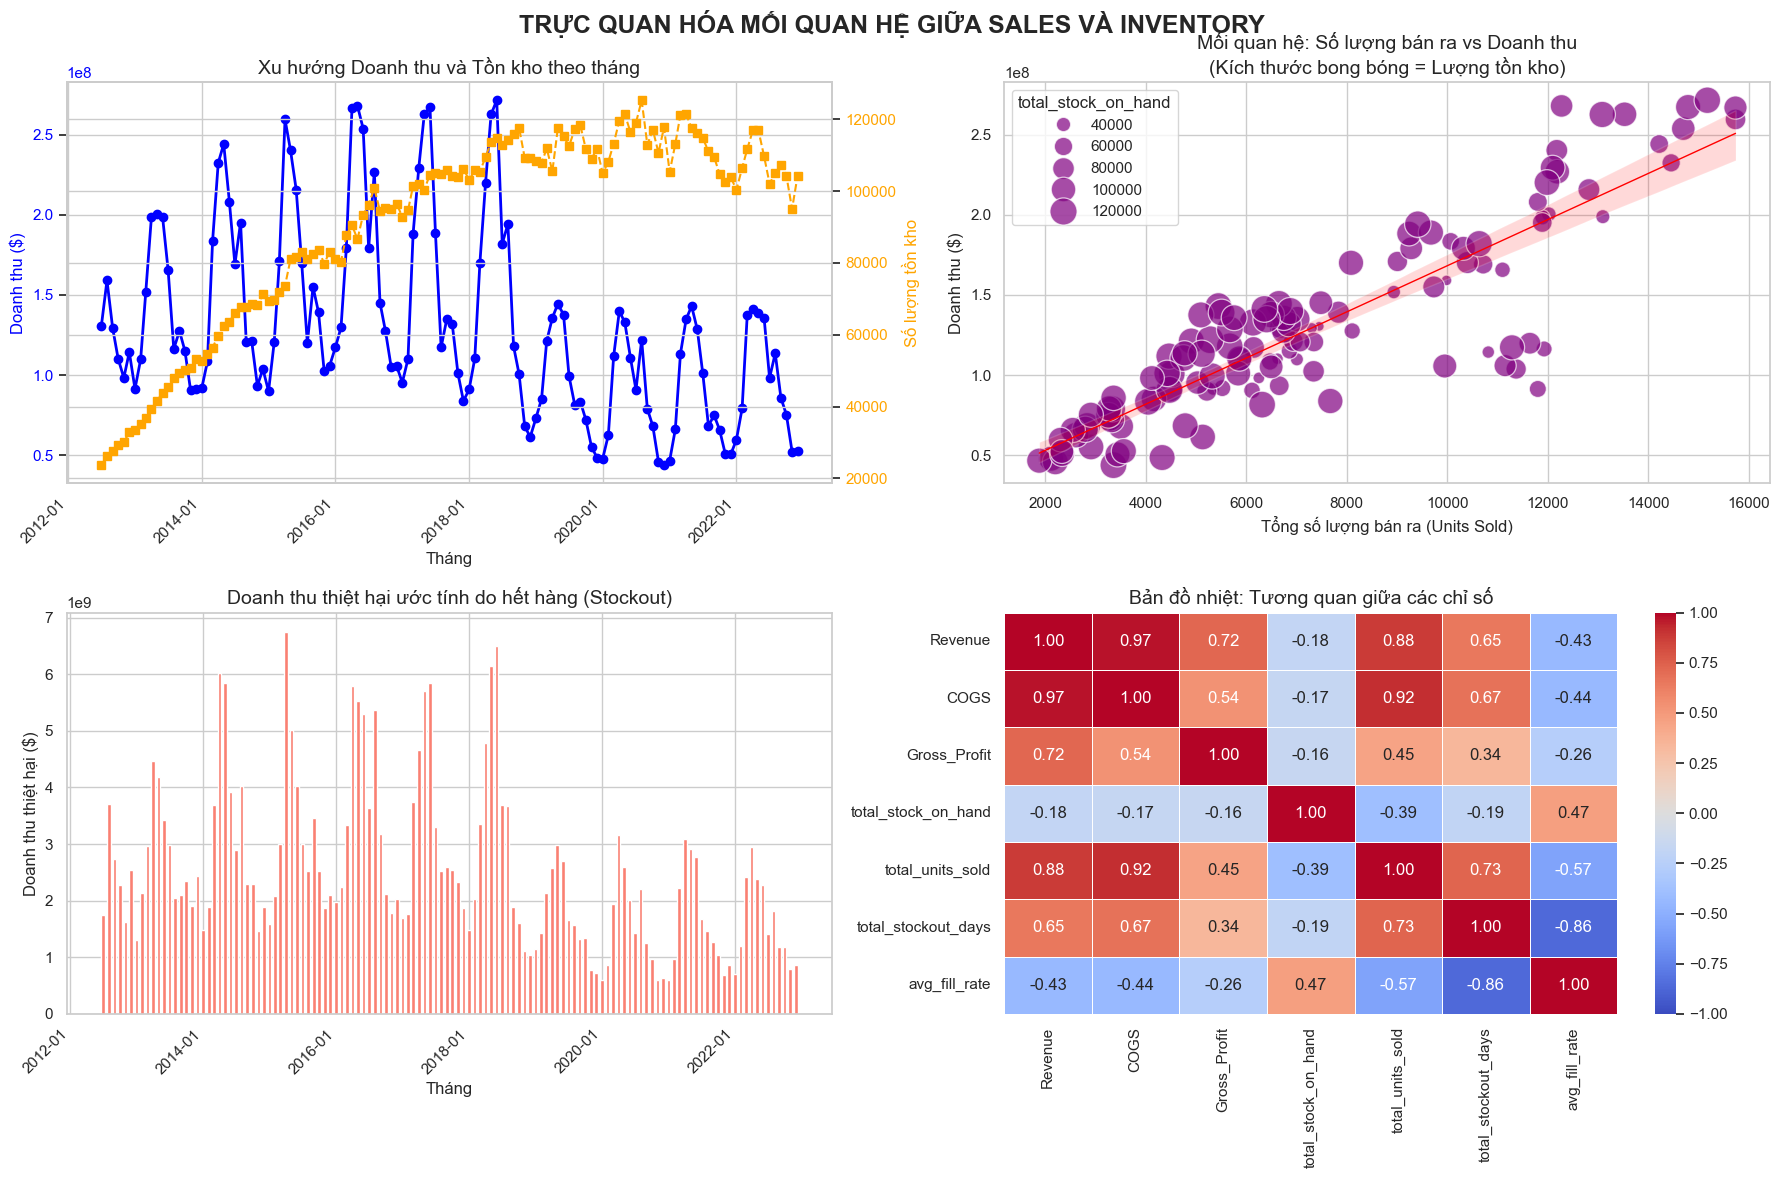

In [1]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu từ file CSV
df_sales = pd.read_csv('../dataset/sales.csv')
df_inventory = pd.read_csv('../dataset/inventory.csv')

# ==========================================
# 2. XỬ LÝ & TỔNG HỢP DỮ LIỆU SALES
# ==========================================
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
# Tạo cột 'year_month' (VD: '2022-10') để làm khóa kết nối
df_sales['year_month'] = df_sales['Date'].dt.to_period('M')

# Nhóm theo tháng và tính tổng Doanh thu, Giá vốn hàng bán
monthly_sales = df_sales.groupby('year_month')[['Revenue', 'COGS']].sum().reset_index()

# Tính thêm Lợi nhuận gộp (Gross Profit)
monthly_sales['Gross_Profit'] = monthly_sales['Revenue'] - monthly_sales['COGS']


# ==========================================
# 3. XỬ LÝ & TỔNG HỢP DỮ LIỆU INVENTORY
# ==========================================
# Sử dụng cột 'year' và 'month' có sẵn để tạo cột 'year_month' chuẩn tương tự file sales
df_inventory['year_month'] = pd.to_datetime(
    df_inventory['year'].astype(str) + '-' + df_inventory['month'].astype(str)
).dt.to_period('M')
# Nhóm các chỉ số kho quan trọng theo tháng
monthly_inventory = df_inventory.groupby('year_month').agg(
    total_stock_on_hand=('stock_on_hand', 'sum'),
    total_units_received=('units_received', 'sum'),
    total_units_sold=('units_sold', 'sum'),
    total_stockout_days=('stockout_days', 'sum'),
    avg_fill_rate=('fill_rate', 'mean')
).reset_index()


# ==========================================
# 4. MERGE VÀ TÍNH TOÁN CÁC CHỈ SỐ MỐI QUAN HỆ
# ==========================================
# Gộp 2 DataFrame lại theo tháng (sử dụng inner join để lấy các tháng xuất hiện ở cả 2 bảng)
df_merged = pd.merge(monthly_sales, monthly_inventory, on='year_month', how='inner')

# Tính toán một số thuộc tính quan trọng để đánh giá mối quan hệ:
# a. Tương quan Giá vốn hàng bán (COGS) trên số lượng tồn kho (Chi phí trung bình ẩn)
df_merged['COGS_per_Stock_Unit'] = df_merged['COGS'] / df_merged['total_stock_on_hand'].replace(0, np.nan)

# b. Tương quan Doanh thu trên lượng hàng bán ra (Giá bán trung bình ước tính trên 1 đơn vị)
df_merged['Revenue_per_Unit_Sold'] = df_merged['Revenue'] / df_merged['total_units_sold'].replace(0, np.nan)

# c. Tỷ lệ mất doanh thu tiềm năng do thiếu hàng (Đo lường tác động của stockout_days lên Revenue)
# Giả định: Doanh thu trung bình mỗi ngày * số ngày hết hàng
revenue_per_day = df_merged['Revenue'] / 30 
df_merged['Estimated_Lost_Revenue'] = revenue_per_day * df_merged['total_stockout_days']

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_theme(style="whitegrid")

# ==========================================
# FIX TRỤC X: Chuyển Period sang Datetime chuẩn
# ==========================================
df_merged['month_dt'] = df_merged['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('TRỰC QUAN HÓA MỐI QUAN HỆ GIỮA SALES VÀ INVENTORY', fontsize=18, fontweight='bold')

# ==========================================
# 1. BIỂU ĐỒ ĐƯỜNG 2 TRỤC (Đã fix trục X)
# ==========================================
ax1 = axes[0, 0]
ax1.plot(df_merged['month_dt'], df_merged['Revenue'], color='blue', marker='o', label='Revenue', linewidth=2)
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Doanh thu ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(df_merged['month_dt'], df_merged['total_stock_on_hand'], color='orange', marker='s', linestyle='--', label='Stock on Hand')
ax2.set_ylabel('Số lượng tồn kho', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Ép định dạng ngày hiển thị thành YYYY-MM và xoay 45 độ
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right') # ha='right' giúp nhãn không bị lệch
ax1.set_title('Xu hướng Doanh thu và Tồn kho theo tháng', fontsize=14)
# ==========================================
# 2. SCATTER PLOT (Giữ nguyên)
# ==========================================
sns.scatterplot(
    data=df_merged, x='total_units_sold', y='Revenue', 
    size='total_stock_on_hand', sizes=(50, 400), alpha=0.7, ax=axes[0, 1], color='purple'
)
sns.regplot(data=df_merged, x='total_units_sold', y='Revenue', scatter=False, ax=axes[0, 1], color='red', line_kws={"linewidth":1})
axes[0, 1].set_title('Mối quan hệ: Số lượng bán ra vs Doanh thu\n(Kích thước bong bóng = Lượng tồn kho)', fontsize=14)
axes[0, 1].set_xlabel('Tổng số lượng bán ra (Units Sold)')
axes[0, 1].set_ylabel('Doanh thu ($)')

# ==========================================
# 3. BAR CHART (Đã fix trục X)
# ==========================================
# Dùng matplotlib bar thay vì seaborn barplot để trục X datetime đồng bộ hoàn hảo
# width=20 (tính bằng ngày) giúp các cột có độ rộng vừa phải
axes[1, 0].bar(df_merged['month_dt'], df_merged['Estimated_Lost_Revenue'], color='salmon', width=20)
axes[1, 0].set_title('Doanh thu thiệt hại ước tính do hết hàng (Stockout)', fontsize=14)
axes[1, 0].set_xlabel('Tháng')
axes[1, 0].set_ylabel('Doanh thu thiệt hại ($)')

# Ép định dạng và xoay nhãn tương tự biểu đồ đường
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

# ==========================================
# 4. HEATMAP (Giữ nguyên)
# ==========================================
corr_cols = ['Revenue', 'COGS', 'Gross_Profit', 'total_stock_on_hand', 
             'total_units_sold', 'total_stockout_days', 'avg_fill_rate']
corr_matrix = df_merged[corr_cols].corr()

sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
    vmin=-1, vmax=1, linewidths=.5, ax=axes[1, 1]
)
axes[1, 1].set_title('Bản đồ nhiệt: Tương quan giữa các chỉ số', fontsize=14)

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

# Inventory health

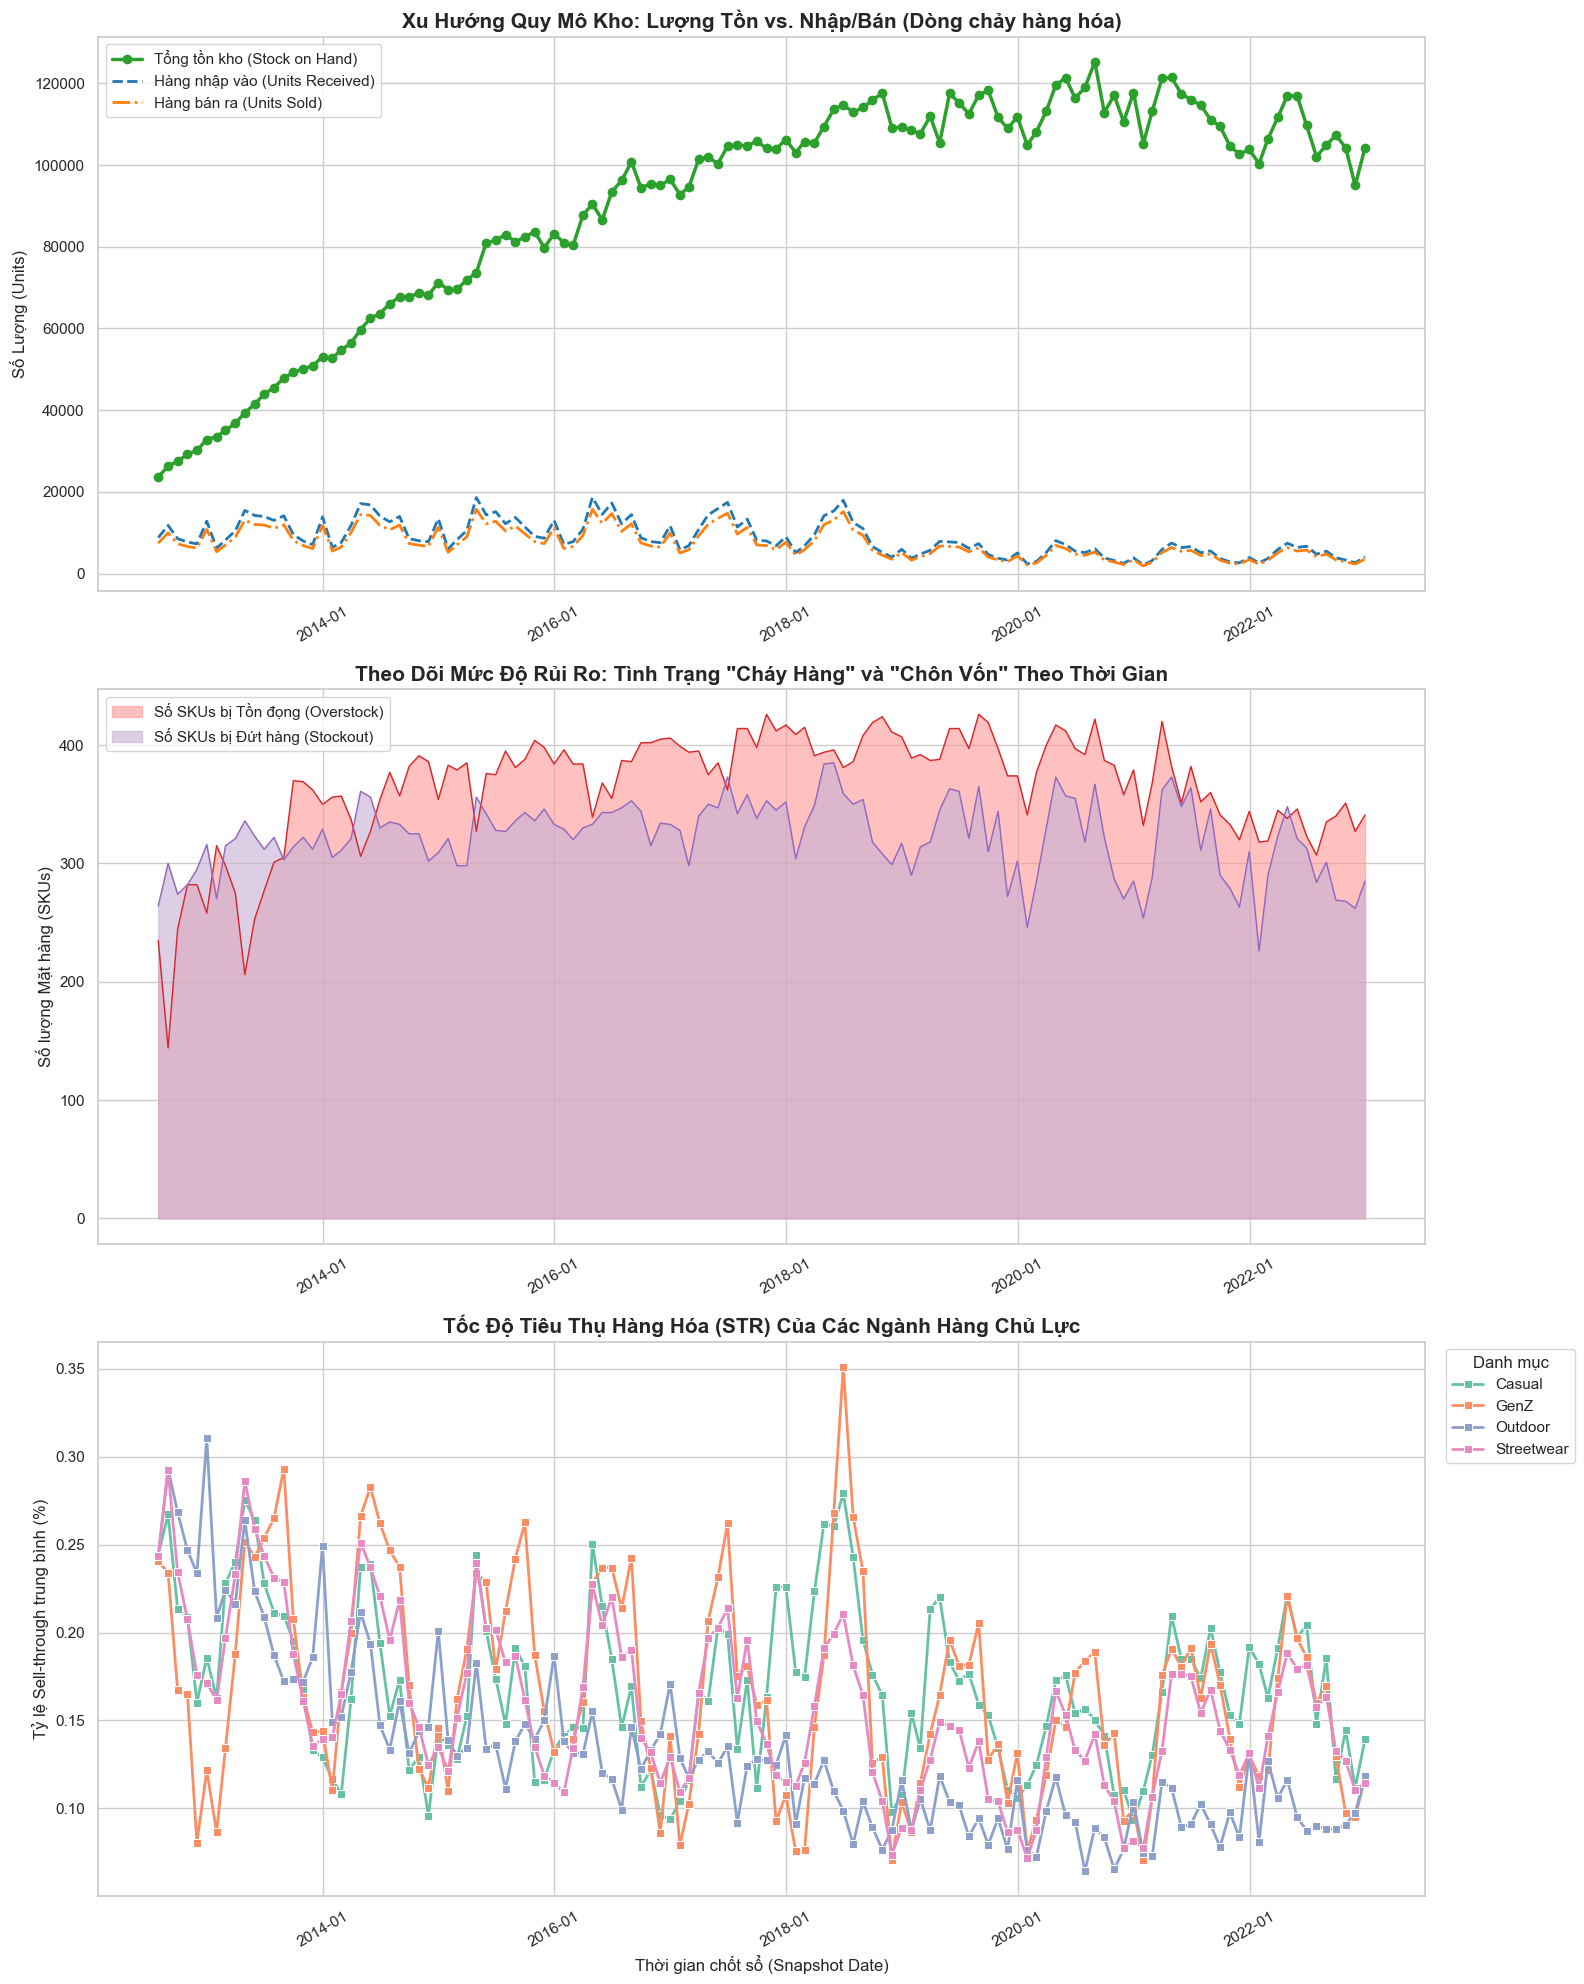

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ==========================================
# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
df_inv = pd.read_csv('../dataset/inventory.csv')

# Chuyển đổi định dạng ngày tháng và sắp xếp
df_inv['snapshot_date'] = pd.to_datetime(df_inv['snapshot_date'])
df_inv = df_inv.sort_values('snapshot_date')

# Tạo cột Năm-Tháng (YYYY-MM) để dễ dàng gom nhóm theo tháng nếu dữ liệu theo ngày quá nhiễu
df_inv['year_month'] = df_inv['snapshot_date'].dt.to_period('M')

# ==========================================
# 2. XỬ LÝ DỮ LIỆU CHUỖI THỜI GIAN (TIME-SERIES)
# ==========================================
# Tổng hợp Dòng chảy Hàng hóa (Lượng tồn, Lượng nhập, Lượng bán) theo từng mốc thời gian
flow_trend = df_inv.groupby('snapshot_date').agg(
    total_stock=('stock_on_hand', 'sum'),
    total_received=('units_received', 'sum'),
    total_sold=('units_sold', 'sum')
).reset_index()

# Tổng hợp Số lượng mã hàng (SKUs) bị rủi ro (Stockout/Overstock) qua từng kỳ
risk_trend = df_inv.groupby('snapshot_date').agg(
    stockout_count=('stockout_flag', 'sum'), # Vì flag là 1/0 nên sum() = đếm số lượng
    overstock_count=('overstock_flag', 'sum')
).reset_index()

# Đánh giá hiệu suất: Tốc độ bán (Sell-through rate) trung bình theo Category qua thời gian
# Lấy Top 4 Category có lượng tồn kho lớn nhất để tránh biểu đồ quá rối
top_cats = df_inv.groupby('category')['stock_on_hand'].sum().nlargest(4).index
eff_trend = df_inv[df_inv['category'].isin(top_cats)].groupby(['snapshot_date', 'category'])['sell_through_rate'].mean().reset_index()

# ==========================================
# 3. TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(16, 20))

# -------------------------------------------------------------------
# BIỂU ĐỒ 1: BIẾN ĐỘNG QUY MÔ TỒN KHO VÀ DÒNG CHẢY HÀNG HÓA
# -------------------------------------------------------------------
ax1 = axes[0]
ax1.plot(flow_trend['snapshot_date'], flow_trend['total_stock'], label='Tổng tồn kho (Stock on Hand)', color='#2ca02c', linewidth=2.5, marker='o')
ax1.plot(flow_trend['snapshot_date'], flow_trend['total_received'], label='Hàng nhập vào (Units Received)', color='#1f77b4', linestyle='--', linewidth=2)
ax1.plot(flow_trend['snapshot_date'], flow_trend['total_sold'], label='Hàng bán ra (Units Sold)', color='#ff7f0e', linestyle='-.', linewidth=2)

ax1.set_title('Xu Hướng Quy Mô Kho: Lượng Tồn vs. Nhập/Bán (Dòng chảy hàng hóa)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Số Lượng (Units)', fontsize=12)
ax1.legend(loc='upper left')

# -------------------------------------------------------------------
# BIỂU ĐỒ 2: THEO DÕI RỦI RO (THIẾU HÀNG / TỒN ĐỌNG) QUA CÁC KỲ
# -------------------------------------------------------------------
ax2 = axes[1]
# Dùng biểu đồ miền (Area chart) để thấy rõ khối lượng rủi ro
ax2.fill_between(risk_trend['snapshot_date'], risk_trend['overstock_count'], color='#ff9896', alpha=0.6, label='Số SKUs bị Tồn đọng (Overstock)')
ax2.fill_between(risk_trend['snapshot_date'], risk_trend['stockout_count'], color='#c5b0d5', alpha=0.6, label='Số SKUs bị Đứt hàng (Stockout)')
ax2.plot(risk_trend['snapshot_date'], risk_trend['overstock_count'], color='#d62728', linewidth=1)
ax2.plot(risk_trend['snapshot_date'], risk_trend['stockout_count'], color='#9467bd', linewidth=1)

ax2.set_title('Theo Dõi Mức Độ Rủi Ro: Tình Trạng "Cháy Hàng" và "Chôn Vốn" Theo Thời Gian', fontsize=15, fontweight='bold')
ax2.set_ylabel('Số lượng Mặt hàng (SKUs)', fontsize=12)
ax2.legend(loc='upper left')

# -------------------------------------------------------------------
# BIỂU ĐỒ 3: HIỆU SUẤT ĐẨY HÀNG (SELL-THROUGH RATE) THEO DANH MỤC
# -------------------------------------------------------------------
ax3 = axes[2]
sns.lineplot(
    data=eff_trend, 
    x='snapshot_date', 
    y='sell_through_rate', 
    hue='category', 
    palette='Set2', 
    linewidth=2, 
    marker='s',
    ax=ax3
)

ax3.set_title('Tốc Độ Tiêu Thụ Hàng Hóa (STR) Của Các Ngành Hàng Chủ Lực', fontsize=15, fontweight='bold')
ax3.set_ylabel('Tỷ lệ Sell-through trung bình (%)', fontsize=12)
ax3.set_xlabel('Thời gian chốt sổ (Snapshot Date)', fontsize=12)
ax3.legend(title='Danh mục', bbox_to_anchor=(1.01, 1), loc='upper left')

# Định dạng chung cho trục X (Thời gian) của cả 3 biểu đồ
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Inventory tồn theo mặt hàng

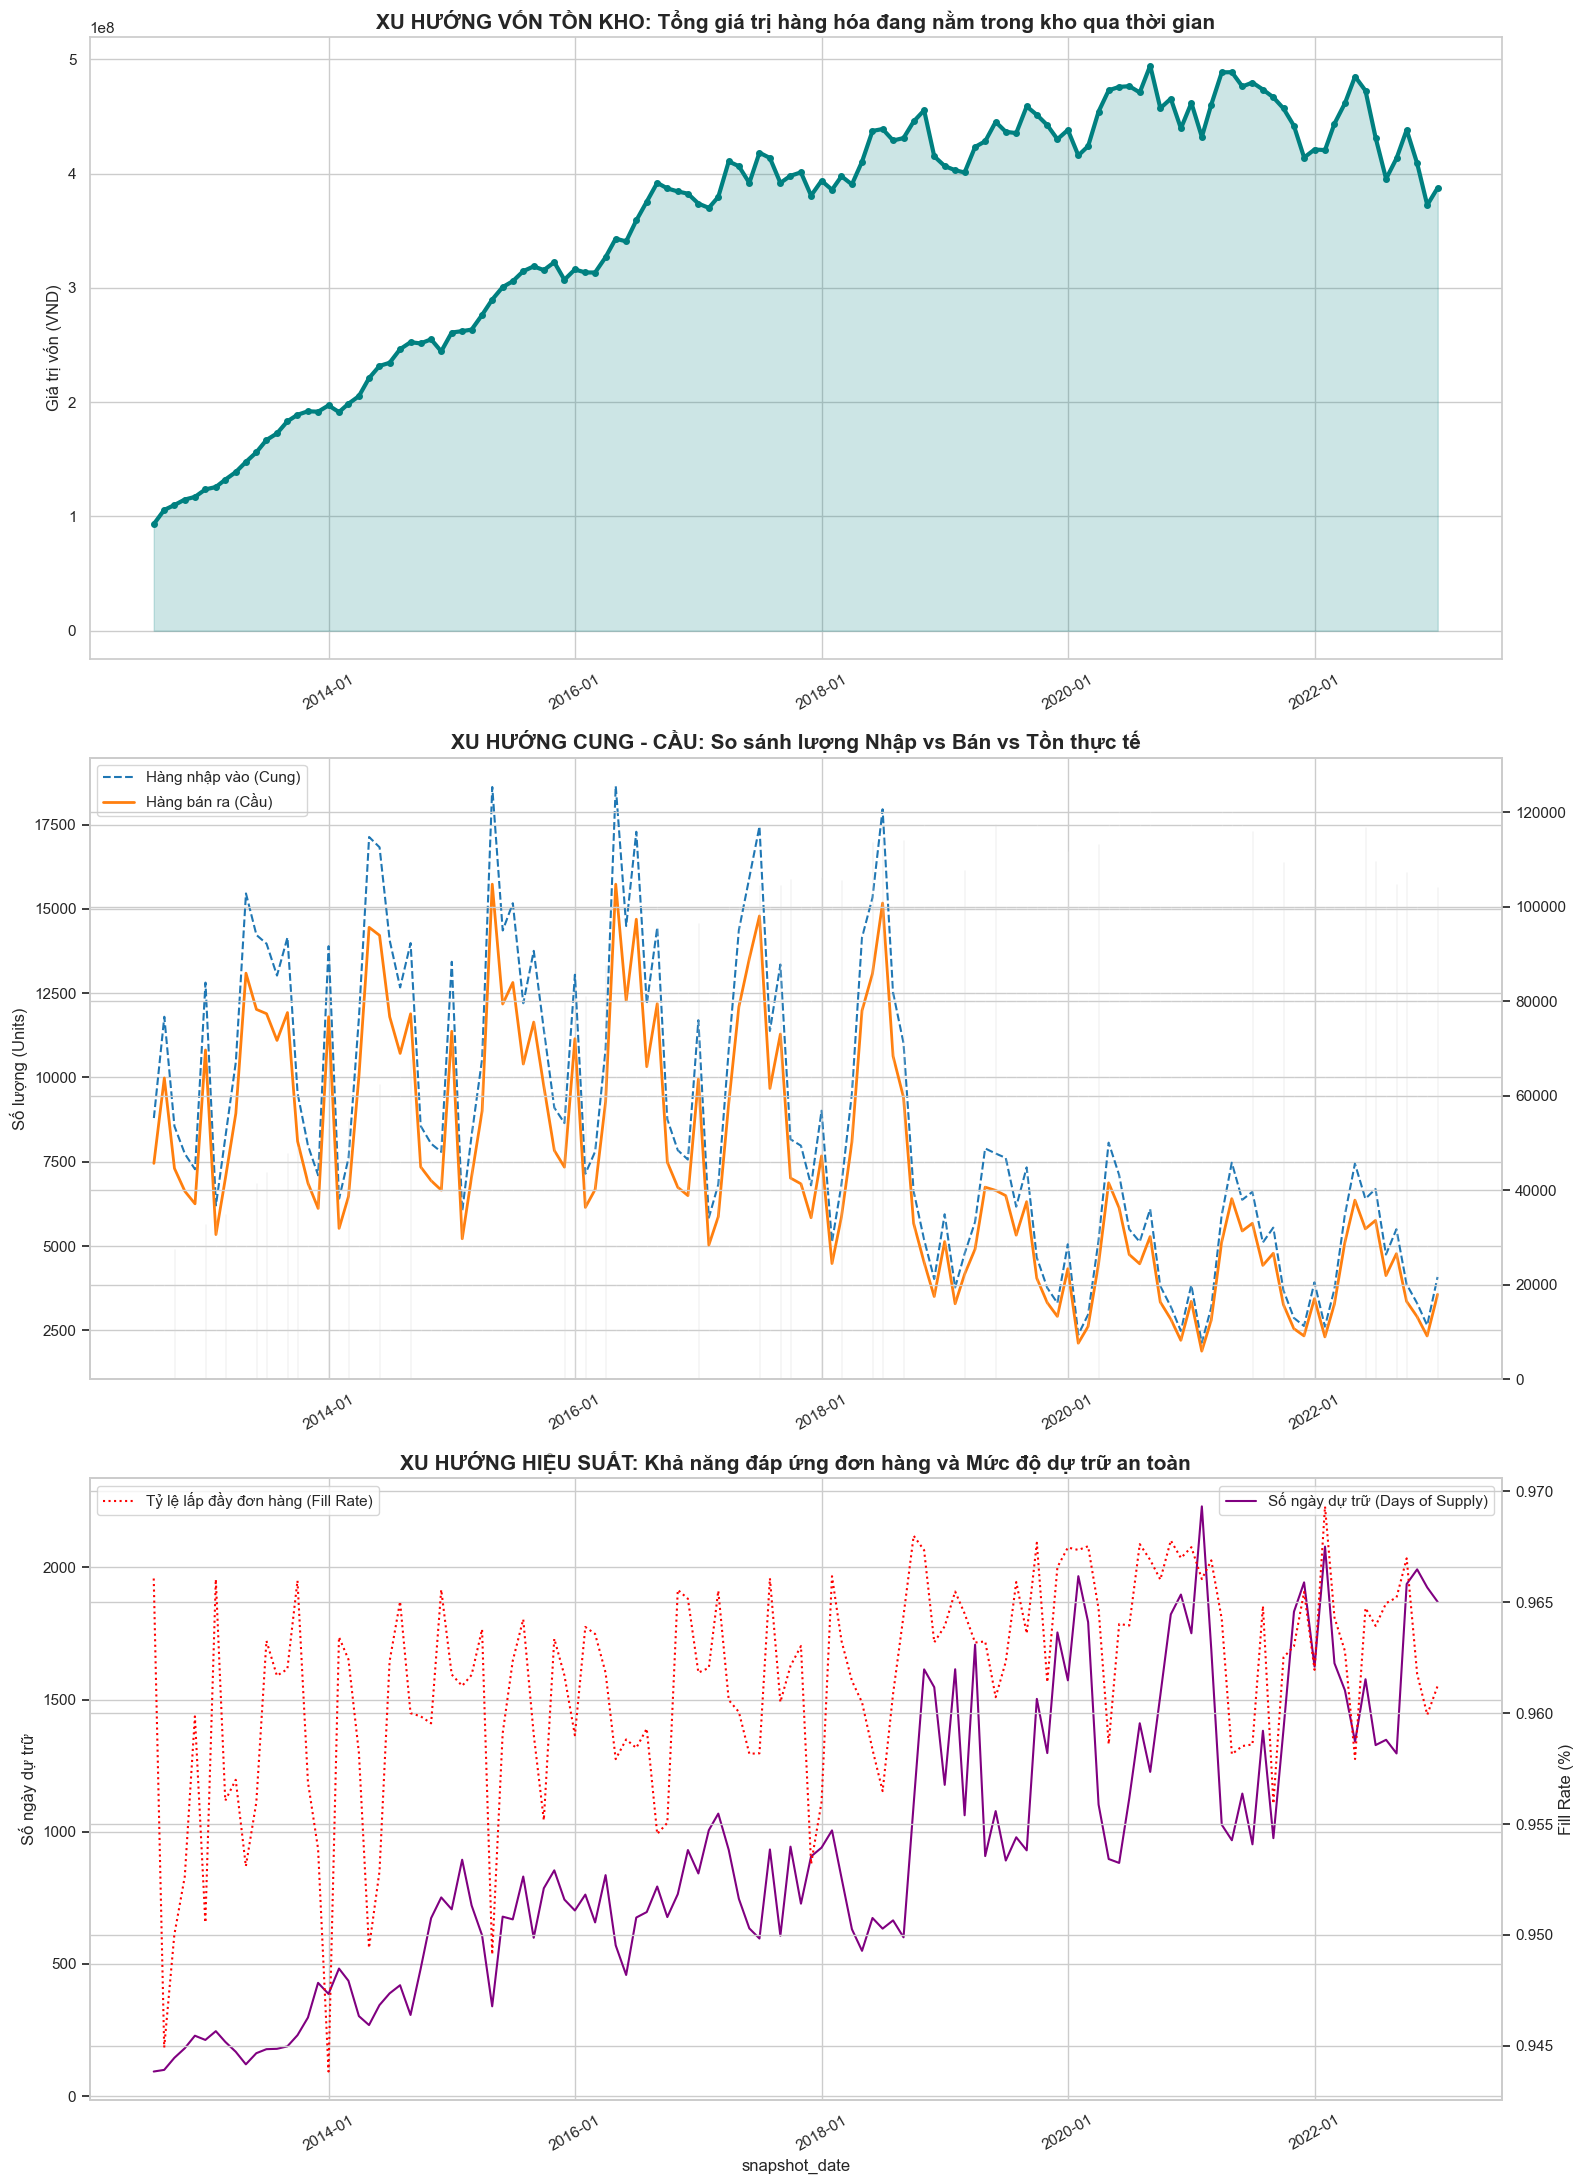

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. ĐỌC DỮ LIỆU
df_inv = pd.read_csv('../dataset/inventory.csv')
df_prod = pd.read_csv('../dataset/products.csv')

# 2. XỬ LÝ DỮ LIỆU CHUỖI THỜI GIAN
df_inv['snapshot_date'] = pd.to_datetime(df_inv['snapshot_date'])
df_inv = df_inv.sort_values('snapshot_date')

# Ghép với bảng products để lấy giá vốn (cogs) tính giá trị tiền tồn kho
df_trend = pd.merge(df_inv, df_prod[['product_id', 'cogs']], on='product_id', how='left')
df_trend['total_inventory_value'] = df_trend['stock_on_hand'] * df_trend['cogs']

# Gom nhóm theo thời gian (Snapshot)
time_series = df_trend.groupby('snapshot_date').agg({
    'total_inventory_value': 'sum',
    'stock_on_hand': 'sum',
    'units_sold': 'sum',
    'units_received': 'sum',
    'days_of_supply': 'mean',
    'fill_rate': 'mean'
}).reset_index()

# 3. TRỰC QUAN HÓA XU HƯỚNG
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(16, 22))

# --- Biểu đồ 1: Xu hướng Giá trị vốn tồn kho (Tài chính) ---
ax1 = axes[0]
ax1.fill_between(time_series['snapshot_date'], time_series['total_inventory_value'], color='teal', alpha=0.2)
ax1.plot(time_series['snapshot_date'], time_series['total_inventory_value'], color='teal', linewidth=3, marker='o', markersize=4)
ax1.set_title('XU HƯỚNG VỐN TỒN KHO: Tổng giá trị hàng hóa đang nằm trong kho qua thời gian', fontsize=15, fontweight='bold')
ax1.set_ylabel('Giá trị vốn (VND)', fontsize=12)

# --- Biểu đồ 2: Cân bằng Cung - Cầu (Inventory Health) ---
ax2 = axes[1]
ax2.plot(time_series['snapshot_date'], time_series['units_received'], label='Hàng nhập vào (Cung)', color='#1f77b4', linestyle='--')
ax2.plot(time_series['snapshot_date'], time_series['units_sold'], label='Hàng bán ra (Cầu)', color='#ff7f0e', linewidth=2)
# Tạo trục Y phụ cho Stock on Hand
ax2_twin = ax2.twinx()
ax2_twin.bar(time_series['snapshot_date'], time_series['stock_on_hand'], alpha=0.15, color='grey', label='Tổng lượng tồn (Units)')

ax2.set_title('XU HƯỚNG CUNG - CẦU: So sánh lượng Nhập vs Bán vs Tồn thực tế', fontsize=15, fontweight='bold')
ax2.set_ylabel('Số lượng (Units)', fontsize=12)
ax2.legend(loc='upper left')

# --- Biểu đồ 3: Hiệu suất vận hành (Days of Supply & Fill Rate) ---
ax3 = axes[2]
ax3_twin = ax3.twinx()
sns.lineplot(data=time_series, x='snapshot_date', y='days_of_supply', ax=ax3, color='purple', label='Số ngày dự trữ (Days of Supply)')
sns.lineplot(data=time_series, x='snapshot_date', y='fill_rate', ax=ax3_twin, color='red', label='Tỷ lệ lấp đầy đơn hàng (Fill Rate)', linestyle=':')

ax3.set_title('XU HƯỚNG HIỆU SUẤT: Khả năng đáp ứng đơn hàng và Mức độ dự trữ an toàn', fontsize=15, fontweight='bold')
ax3.set_ylabel('Số ngày dự trữ', fontsize=12)
ax3_twin.set_ylabel('Fill Rate (%)', fontsize=12)

# Định dạng thời gian trục X
for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Vòng quay tồn kho

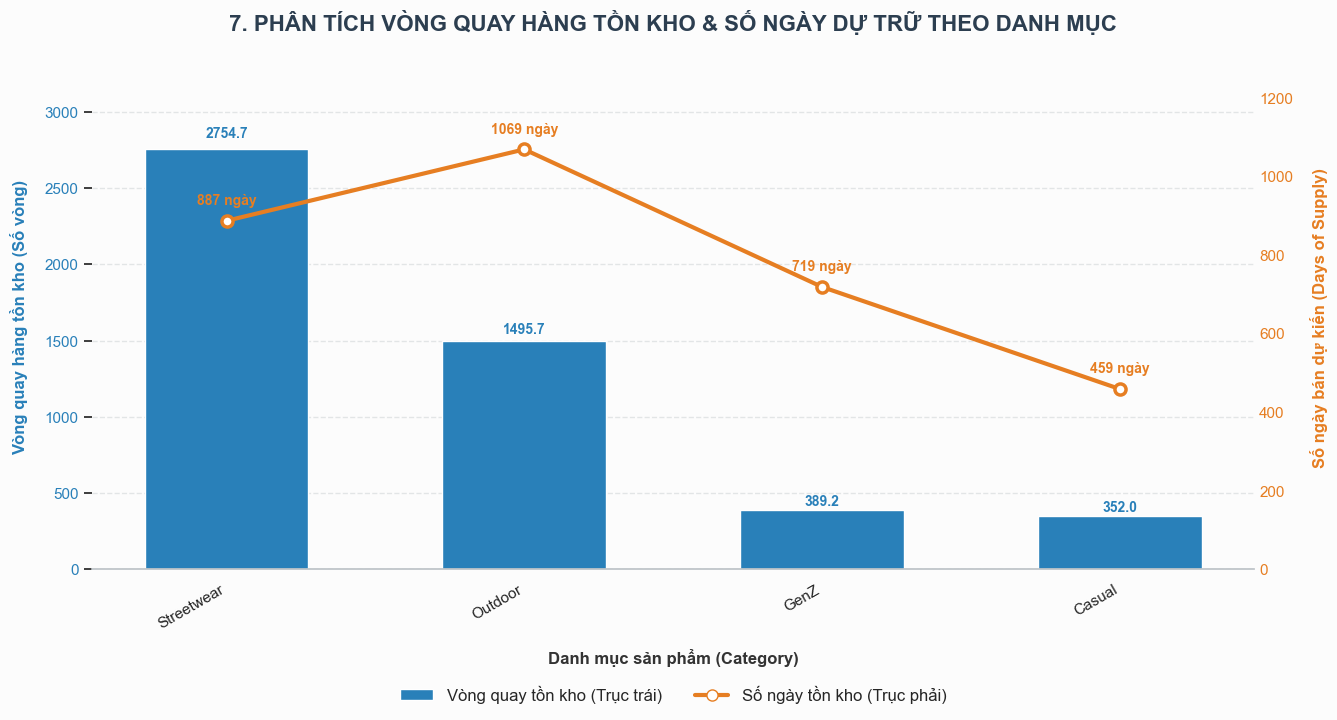

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt giao diện hiện đại, nền sáng
sns.set_theme(style="white", rc={"axes.facecolor": "#fcfcfc", "figure.facecolor": "#fcfcfc"})

try:
    # 1. ĐỌC DỮ LIỆU
    inventory = pd.read_csv('../dataset/inventory.csv')

    # 2. XỬ LÝ & TÍNH TOÁN VÒNG QUAY TỒN KHO THEO DANH MỤC
    # Gom nhóm theo category: Tính Tổng bán ra và Trung bình tồn kho
    inv_summary = inventory.groupby('category').agg(
        Total_Sold=('units_sold', 'sum'),
        Avg_Stock=('stock_on_hand', 'mean'),
        Avg_Days_Supply=('days_of_supply', 'mean')
    ).reset_index()

    # Xử lý lỗi chia cho 0 (nếu có category nào Avg_Stock = 0)
    inv_summary['Avg_Stock'] = inv_summary['Avg_Stock'].replace(0, 1)

    # Tính Vòng quay hàng tồn kho (Turnover)
    inv_summary['Inventory_Turnover'] = inv_summary['Total_Sold'] / inv_summary['Avg_Stock']

    # Sắp xếp từ vòng quay cao nhất đến thấp nhất
    inv_summary = inv_summary.sort_values('Inventory_Turnover', ascending=False)

    # 3. VẼ BIỂU ĐỒ TRỰC QUAN (COMBO CHART)
    fig, ax1 = plt.subplots(figsize=(15, 8))
    
    x = np.arange(len(inv_summary))
    width = 0.55

    color_turnover = '#2980b9'  # Xanh dương đậm cho Vòng quay
    color_days = '#e67e22'      # Cam đậm cho Số ngày tồn kho

    # Vẽ cột (Vòng quay tồn kho) trên trục Y thứ nhất
    bars = ax1.bar(x, inv_summary['Inventory_Turnover'], width, color=color_turnover, edgecolor='white', linewidth=1)
    ax1.set_ylabel('Vòng quay hàng tồn kho (Số vòng)', fontsize=12, fontweight='bold', color=color_turnover, labelpad=12)
    ax1.tick_params(axis='y', labelcolor=color_turnover)
    
    # Cấu hình lưới và trục X
    ax1.grid(axis='y', linestyle='--', alpha=0.4, color='#bdc3c7')
    ax1.set_axisbelow(True)
    ax1.set_xticks(x)
    
    # Rút gọn tên Category nếu quá dài
    short_cats = [str(cat)[:20] + '...' if len(str(cat)) > 20 else str(cat) for cat in inv_summary['category']]
    ax1.set_xticklabels(short_cats, rotation=30, ha='right', fontsize=11)
    ax1.set_xlabel('Danh mục sản phẩm (Category)', fontsize=12, fontweight='bold', labelpad=12, color='#333333')

    # Vẽ đường (Số ngày tồn kho - Days of Supply) trên trục Y thứ hai
    ax2 = ax1.twinx()
    ax2.plot(x, inv_summary['Avg_Days_Supply'], color=color_days, marker='o', 
             mfc='white', mec=color_days, mew=2.5, linewidth=3, markersize=8)
    
    ax2.set_ylabel('Số ngày bán dự kiến (Days of Supply)', fontsize=12, fontweight='bold', color=color_days, labelpad=12)
    ax2.tick_params(axis='y', labelcolor=color_days, length=0)
    ax2.grid(False) # Tắt lưới trục 2 để tránh đan chéo rối mắt

    # Dọn dẹp viền biểu đồ cho thanh thoát
    for spine in ['top', 'left', 'right']:
        ax1.spines[spine].set_visible(False)
        ax2.spines[spine].set_visible(False)
    ax1.spines['bottom'].set_color('#bdc3c7')
    ax2.spines['bottom'].set_visible(False)

    # Gắn nhãn số liệu trực tiếp lên biểu đồ
    # Nhãn cho cột (Vòng quay)
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:.1f}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color=color_turnover)
                 
    # Nhãn cho đường (Số ngày)
    for i, val in enumerate(inv_summary['Avg_Days_Supply']):
        ax2.text(i, val + (ax2.get_ylim()[1] * 0.03), f'{val:.0f} ngày', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color=color_days)

    # Nâng trần trục Y để chữ không bị cắt
    ax1.set_ylim(0, inv_summary['Inventory_Turnover'].max() * 1.2)
    ax2.set_ylim(0, inv_summary['Avg_Days_Supply'].max() * 1.2)

    # Thêm Legend thủ công
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor=color_turnover, edgecolor='white', label='Vòng quay tồn kho (Trục trái)'),
        Line2D([0], [0], color=color_days, lw=3, marker='o', mfc='white', mec=color_days, markersize=8, label='Số ngày tồn kho (Trục phải)')
    ]
    ax1.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.2), 
               ncol=2, frameon=False, fontsize=12)

    plt.title('7. PHÂN TÍCH VÒNG QUAY HÀNG TỒN KHO & SỐ NGÀY DỰ TRỮ THEO DANH MỤC', fontsize=16, fontweight='900', pad=25, color='#2c3e50')
    plt.subplots_adjust(bottom=0.25)
    
    plt.show()

except FileNotFoundError as e:
    print(f"Lỗi: Không tìm thấy file dữ liệu - {e}")